# The objective is to help telecom companies identify
# customers who may leave and take preventive actions .

Import Required Libraries

In [2]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt 

Load the dataset 

In [3]:
data = pd.read_csv("Telco-Customer-Churn.csv")

Explore Dataset

In [4]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
data.shape

(7043, 21)

In [6]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [7]:
data.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


Dropping the customer Id column cause its not relevant for training the model \
and also not currntly relevant for data analysis 

In [8]:
data = data.drop("customerID" , axis = 1)

In [9]:
data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Now I will visualize the data and try to provide insights on this data based on each column 

In [10]:
data["gender"].value_counts()

gender
Male      3555
Female    3488
Name: count, dtype: int64

In [11]:
pd.crosstab(data["gender"], data["Churn"])

Churn,No,Yes
gender,,
Female,2549,939
Male,2625,930


from this analysis it shows that : \
 out of 3555 male customers over 2625 stayed thats ovver 73.83 % stayed \
and out of 3488 female customer over 2549  stayed thats over 73.07 % stayed 

that make out of total 7043 customers 4974 stayed thats over 70.33 % customers stayed 

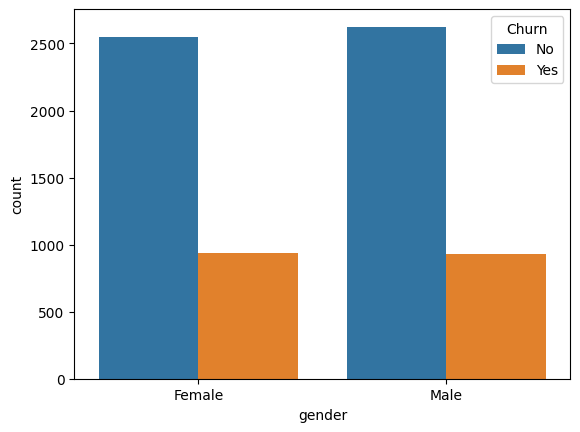

In [12]:
sns.countplot(x = "gender" , hue = "Churn" , data = data)
plt.show()

In [13]:
data["MultipleLines"].value_counts()

MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

In [14]:
pd.crosstab(data["MultipleLines"], data["Churn"])

Churn,No,Yes
MultipleLines,,
No,2541,849
No phone service,512,170
Yes,2121,850


Out of 7043 total customers: \
among 3390 customers who had no multiple lines , 2541 stayed, which is 74.95 %. \
among 2971 customers who had multiple lines , 2121 stayed, which is 71.39 %. \
among 682 customers who had no phone service , 512 stayed, which is 75.07 % 

overall , a total of 5174 customers stayed , which is 73.46% of all customers.

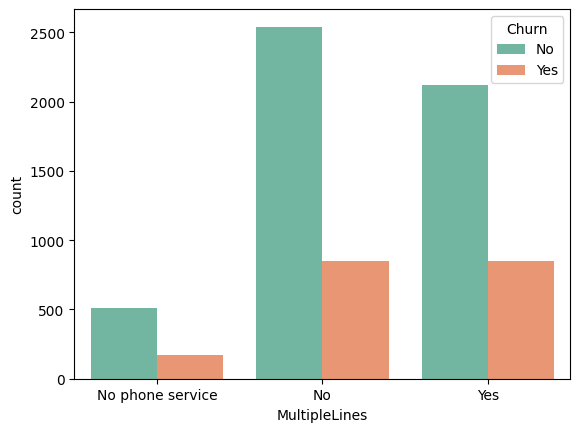

In [15]:
sns.countplot(x = "MultipleLines" , hue = "Churn" , data = data , palette="Set2")
plt.show()

In [16]:
data["Contract"].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

In [17]:
pd.crosstab(data["Contract"], data["Churn"])

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


Out of 7043 total customers :  \
among 3875 had Month-To-Month contract , 2220 stayed which is  57.29 %  \
among 1473 had One Year contract , 1307 stayed shich is  88.73 %  \
among 1695 had Two Year contract , 1647 stayed which is  97.16 %  

overall a total of 5174 customer stayed which is 73.46 %

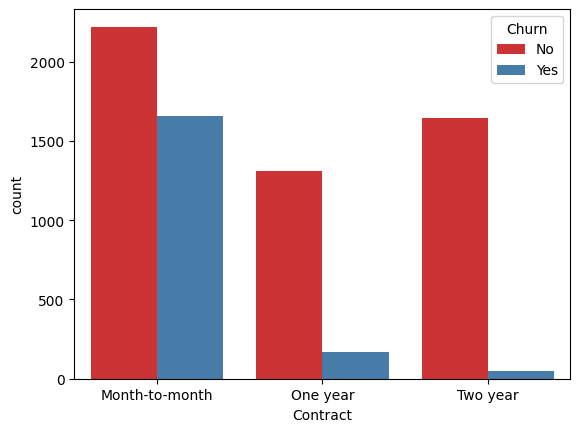

In [18]:
sns.countplot(x = "Contract" , hue = "Churn" , data = data , palette = "Set1")
plt.show()

In [19]:
data["PaymentMethod"].value_counts()

PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

In [20]:
pd.crosstab(data["PaymentMethod"], data["Churn"])

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),1286,258
Credit card (automatic),1290,232
Electronic check,1294,1071
Mailed check,1304,308


Out of 7043 total customers :  \
among 1544 had Bank transfer as payment method , 1286 stayed which is 83.29 %  \
among 1612 had Mailed check as payment method , 1304 stayed which is 80.89 %  \
among 2365 had Electronic check as payment method , 1294 stayed which is 54.71  \
among 1522 had Credit card as payment method , 1290 stayed which is 84.75 %

Overall a total of 5174 stayed which is 73.46 %

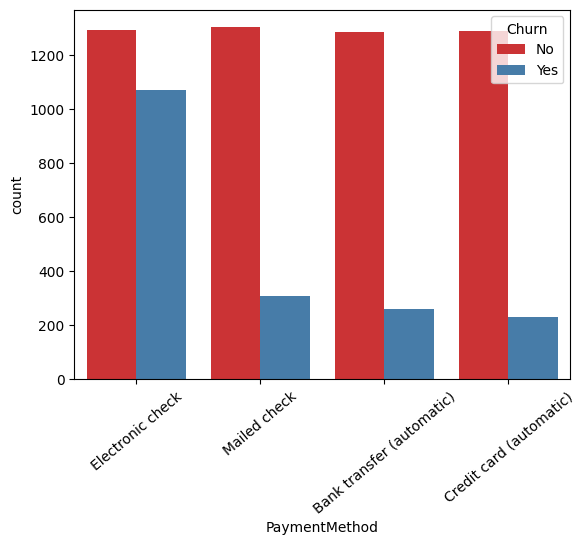

In [21]:
sns.countplot(x = "PaymentMethod" , hue = "Churn" , data = data , palette="Set1")
plt.xticks(rotation = 40)
plt.show()

In [22]:
data["SeniorCitizen"].value_counts()

SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64

In [23]:
pd.crosstab(data["SeniorCitizen"], data["Churn"])

Churn,No,Yes
SeniorCitizen,,
0,4508,1393
1,666,476


Out of 7043 total customers : \
Among 5901 are not Senior Citizen , 4508 stayed which is 76.39 % \
Among 1142 are Senior Citizen , 666 stayed which is 58.31 %

Overall a total of 5174 stayed which is 73.46 % 

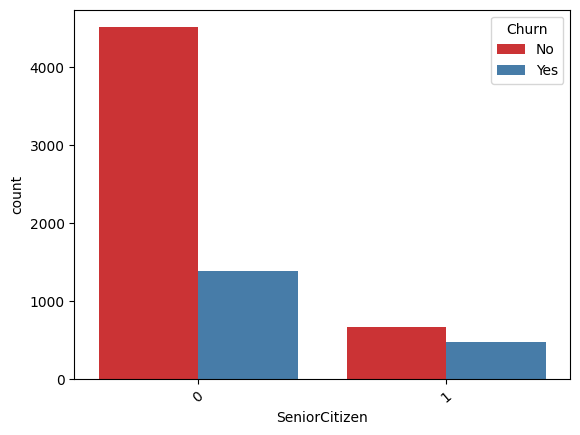

In [24]:
sns.countplot(x = "SeniorCitizen" , hue = "Churn" , data = data , palette="Set1")
plt.xticks(rotation = 40)
plt.show()

In [25]:
data["Dependents"].value_counts()

Dependents
No     4933
Yes    2110
Name: count, dtype: int64

In [26]:
pd.crosstab(data["Dependents"], data["Churn"])

Churn,No,Yes
Dependents,,
No,3390,1543
Yes,1784,326


Out of 7043 total customers : \
Among 4933 are not Dependet , 3390 stayed which is 68.72  % \
Among 2110 are Dependent , 1784	 stayed which is 84.54 % 

Overall a total of 5174 stayed which is 73.46 % 

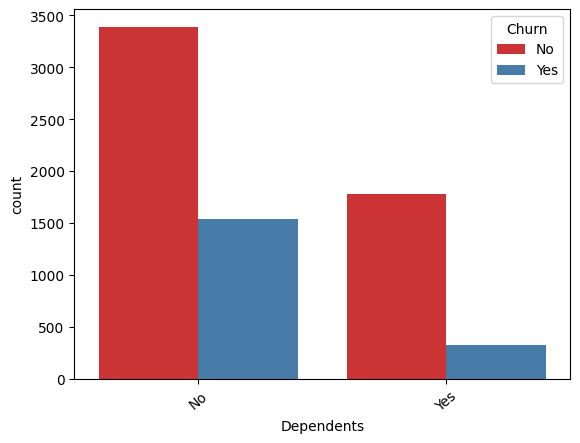

In [27]:
sns.countplot(x = "Dependents" , hue = "Churn" , data = data , palette="Set1")
plt.xticks(rotation = 40)
plt.show()

In [28]:
data["InternetService"].value_counts()

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

In [29]:
pd.crosstab(data["InternetService"], data["Churn"])

Churn,No,Yes
InternetService,,
DSL,1962,459
Fiber optic,1799,1297
No,1413,113


Out of 7043 total customers :  \
Among 3096 are Fiber optic , 1799 stayed which is 58.11 % \
Among 2421 are DSL , 1962 stayed which is 81.04 % \
Among 1526 have No internet , 1413 stayed which is 92.60 % 

Overall a total of 5174 stayed which is 73.46 %

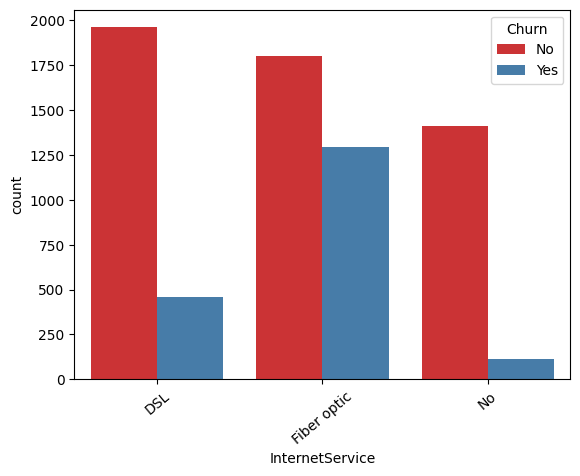

In [30]:
sns.countplot(x = "InternetService" , hue = "Churn" , data = data , palette="Set1")
plt.xticks(rotation = 40)
plt.show()

In [31]:
data["OnlineSecurity"].value_counts()

OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

In [32]:
pd.crosstab(data["OnlineSecurity"], data["Churn"])

Churn,No,Yes
OnlineSecurity,,
No,2037,1461
No internet service,1413,113
Yes,1724,295


Out of 7043 total customers :  \
Among 3498 have No OnlineSecurity , 2037 stayed which is 58.23 %   \
Among 2019 have OnlineSecurity , 1724 stayed which is 85.39 %   \
Among 1526 have No internet service , 1413 stayed which is 92.60 % 

Overall a total of 5174 stayed which is 73.46 %

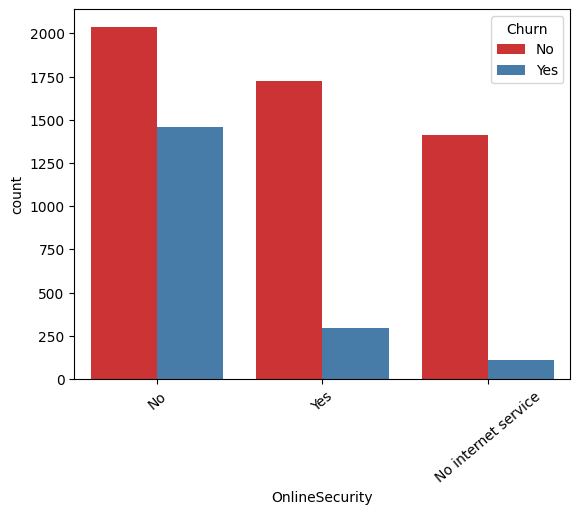

In [33]:
sns.countplot(x = "OnlineSecurity" , hue = "Churn" , data = data , palette="Set1")
plt.xticks(rotation = 40)
plt.show()

In [34]:
data["OnlineBackup"].value_counts()

OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64

In [35]:
pd.crosstab(data["OnlineBackup"], data["Churn"])

Churn,No,Yes
OnlineBackup,,
No,1855,1233
No internet service,1413,113
Yes,1906,523


Out of 7043 total customers :  \
Among 3088 have No OnlineBackup , 1855 stayed which is 60.07 %  \
Among 2429 have OnlineBackup , 1906 stayed which is 78.47 %  \
Among 1526 have No internet service , 1413 stayed which is 92.60 % 

Overall a total of 5174 stayed which is 73.46 %

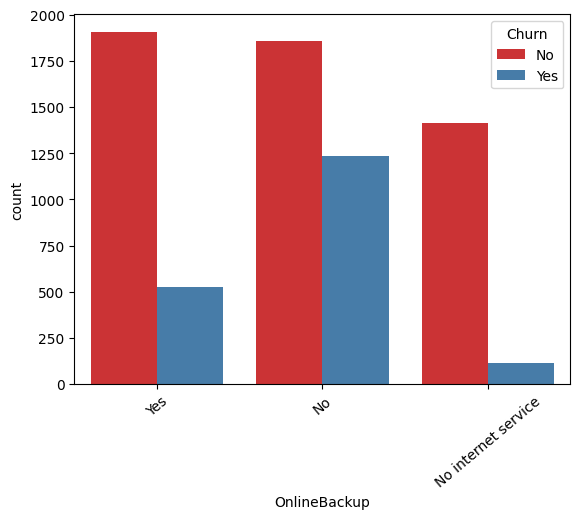

In [36]:
sns.countplot(x = "OnlineBackup" , hue = "Churn" , data = data , palette="Set1")
plt.xticks(rotation = 40)
plt.show()

In [37]:
data["DeviceProtection"].value_counts()

DeviceProtection
No                     3095
Yes                    2422
No internet service    1526
Name: count, dtype: int64

In [38]:
pd.crosstab(data["DeviceProtection"], data["Churn"])

Churn,No,Yes
DeviceProtection,,
No,1884,1211
No internet service,1413,113
Yes,1877,545


Out of 7043 total customers :  \
Among 3095 have No DeviceProtection , 1884 stayed which is 60.87 %  \
Among 2422 have DeviceProtection , 1877 stayed which is 77.50 %  \
Among 1526 have No internet service , 1413 stayed which is 92.60 % 

Overall a total of 5174 stayed which is 73.46 %

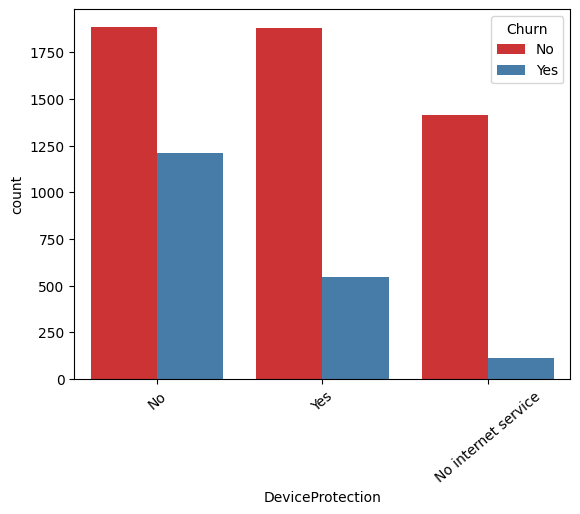

In [39]:
sns.countplot(x = "DeviceProtection" , hue = "Churn" , data = data , palette="Set1")
plt.xticks(rotation = 40)
plt.show()

In [40]:
data["TechSupport"].value_counts()

TechSupport
No                     3473
Yes                    2044
No internet service    1526
Name: count, dtype: int64

In [41]:
pd.crosstab(data["TechSupport"], data["Churn"])

Churn,No,Yes
TechSupport,,
No,2027,1446
No internet service,1413,113
Yes,1734,310


Out of 7043 total customers :  \
Among 3473 have No TechSupport , 2027 stayed which is 58.36 %  \
Among 2044 have TechSupport , 1734 stayed which is 84.83 %   \
Among 1526 have No internet service , 1413 stayed which is 92.60 %   

Overall a total of 5174 stayed which is 73.46 %

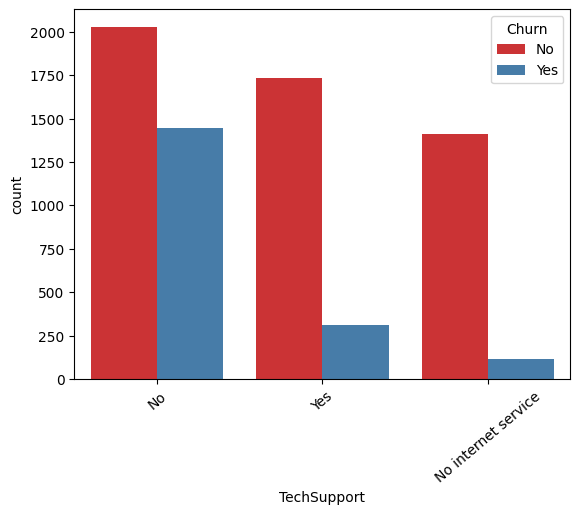

In [42]:
sns.countplot(x = "TechSupport" , hue = "Churn" , data = data , palette="Set1")
plt.xticks(rotation = 40)
plt.show()

In [43]:
data["StreamingTV"].value_counts()

StreamingTV
No                     2810
Yes                    2707
No internet service    1526
Name: count, dtype: int64

In [44]:
pd.crosstab(data["StreamingTV"], data["Churn"])

Churn,No,Yes
StreamingTV,,
No,1868,942
No internet service,1413,113
Yes,1893,814


Out of 7043 total customers :  \
Among 2810 have No StreamingTV , 1868 stayed which is 66.48 %  \
Among 2707 have StreamingTV , 1893 stayed which is 69.93 %  \
Among 1526 have No internet service , 1413 stayed which is 92.60 % 

Overall a total of 5174 stayed which is 73.46 %

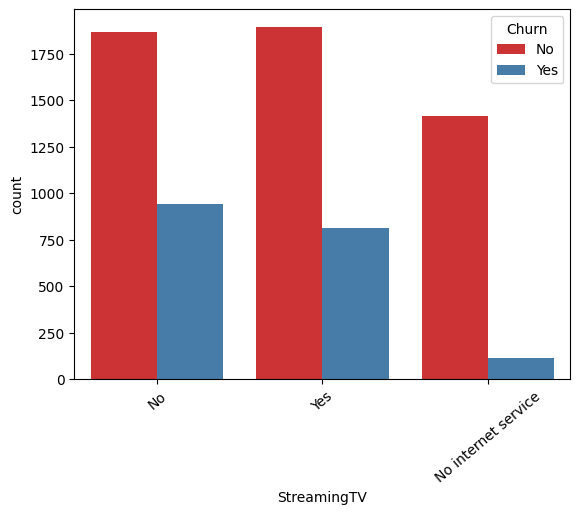

In [45]:
sns.countplot(x = "StreamingTV" , hue = "Churn" , data = data , palette="Set1")
plt.xticks(rotation = 40)
plt.show()

In [46]:
data["StreamingMovies"].value_counts()

StreamingMovies
No                     2785
Yes                    2732
No internet service    1526
Name: count, dtype: int64

In [47]:
pd.crosstab(data["StreamingMovies"], data["Churn"])

Churn,No,Yes
StreamingMovies,,
No,1847,938
No internet service,1413,113
Yes,1914,818


Out of 7043 total customers :  \
Among 2785 have No StreamingMovies , 1847 stayed which is 66.32 %  \
Among 2732 have StreamingMovies , 1914 stayed which is 70.06 %  \
Among 1526 have No internet service , 1413 stayed which is 92.60 % 

Overall a total of 5174 stayed which is 73.46 %

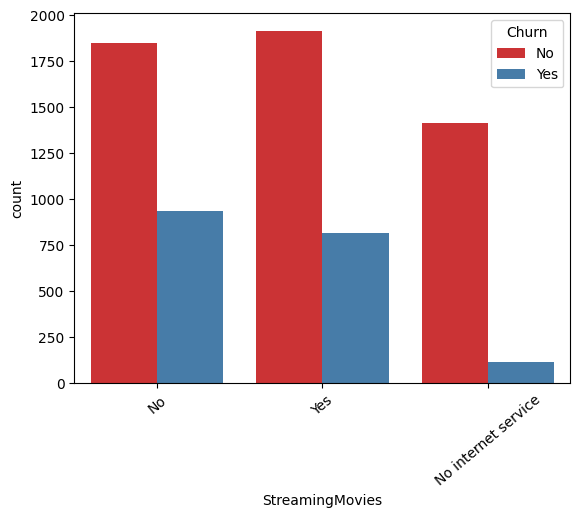

In [48]:
sns.countplot(x = "StreamingMovies" , hue = "Churn" , data = data , palette="Set1")
plt.xticks(rotation = 40)
plt.show()

In [49]:
data["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

The dataset shows a total churn rate of 26.54 % , meaning roughly 1 in 4 customers leave the service.

C:\Users\Admin\AppData\Local\Temp\ipykernel_14868\3490573191.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = "Churn" , data = data , palette="Set1")


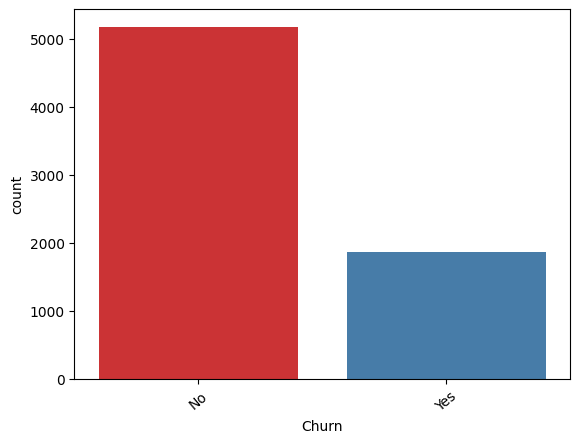

In [50]:
sns.countplot(x = "Churn" , data = data , palette="Set1")
plt.xticks(rotation = 40)
plt.show()

In [51]:
data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [52]:
data.dtypes

gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [53]:
data.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [54]:
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')

data = data.dropna()

In [55]:
data.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [56]:
data.dtypes

gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

In [57]:
X = data.drop('Churn', axis=1)
y = data['Churn']

In [58]:
cat_cols = X.select_dtypes(include='object').columns
num_cols = X.select_dtypes(exclude='object').columns

C:\Users\Admin\AppData\Local\Temp\ipykernel_14868\142198770.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include='object').columns


In [59]:
cat_cols

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='str')

In [60]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [61]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

ct = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ],
    remainder='passthrough'
)

X_encoded = ct.fit_transform(X)

In [62]:
X_encoded

array([[1.0000e+00, 0.0000e+00, 0.0000e+00, ..., 1.0000e+00, 2.9850e+01,
        2.9850e+01],
       [0.0000e+00, 1.0000e+00, 1.0000e+00, ..., 3.4000e+01, 5.6950e+01,
        1.8895e+03],
       [0.0000e+00, 1.0000e+00, 1.0000e+00, ..., 2.0000e+00, 5.3850e+01,
        1.0815e+02],
       ...,
       [1.0000e+00, 0.0000e+00, 0.0000e+00, ..., 1.1000e+01, 2.9600e+01,
        3.4645e+02],
       [0.0000e+00, 1.0000e+00, 0.0000e+00, ..., 4.0000e+00, 7.4400e+01,
        3.0660e+02],
       [0.0000e+00, 1.0000e+00, 1.0000e+00, ..., 6.6000e+01, 1.0565e+02,
        6.8445e+03]], shape=(7032, 45))

In [63]:
encoded_df = pd.DataFrame(X_encoded)
encoded_df.head()

,0,1,2,3,4,5,6,7,8,9,...,35,36,37,38,39,40,41,42,43,44
0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,29.85,29.85
1,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,34.0,56.95,1889.50
2,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,2.0,53.85,108.15
3,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,45.0,42.30,1840.75
4,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,2.0,70.70,151.65


In [64]:
y_encoded

array([0, 0, 1, ..., 0, 1, 0], shape=(7032,))

In [65]:
print(le.classes_)

['No' 'Yes']


In [66]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split

X_train , X_test , y_train , y_test = train_test_split(X_encoded , y_encoded ,test_size = 0.23 , random_state = 42)

In [67]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier()

param_tree = {
    'criterion' : ['gini' , 'entropy'],
    'max_depth' : [3,5,7,9],
    'min_samples_split' : [2,4,6],
    'min_samples_leaf' : [1,2,3]
}


grid_tree = GridSearchCV(tree , param_tree , cv=5)
grid_tree.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 4, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter

In [68]:
print(grid_tree.best_params_)
print(grid_tree.best_score_ * 100)

{'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 6}
79.51640459256907


In [69]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()

param_rf = {
    'n_estimators' : [ 100 , 200 , 300 ] ,
    'criterion' : [ "gini" , "entropy" ] ,
    'max_depth' : [ 2, 3 , 5 , 7 , 9 ] 
}

grid_rf = GridSearchCV(rf , param_rf , cv = 5)
grid_rf.fit(X_train , y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [2, 3, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the

In [70]:
print(grid_rf.best_params_)
print(grid_rf.best_score_ * 100)

{'criterion': 'entropy', 'max_depth': 7, 'n_estimators': 200}
80.49525262714134


In [71]:
from sklearn.neighbors import KNeighborsClassifier 

knn = KNeighborsClassifier()

param_knn = {
    "n_neighbors": [ 3 , 4 , 5 , 6 , 7 ] ,
    "metric" : ["euclidean" , "manhattan"]
    
}

grid_knn = GridSearchCV(knn , param_knn , cv = 5)
grid_knn.fit(X_train , y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'metric': ['euclidean', 'manhattan'], 'n_neighbors': [3, 4, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3

In [72]:
print(grid_knn.best_params_)
print(grid_knn.best_score_ * 100)

{'metric': 'manhattan', 'n_neighbors': 6}
77.33679465713607


In [73]:
best_rf = grid_rf.best_estimator_

y_pred = best_rf.predict(X_test)

In [74]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Test Accuracy:", accuracy_score(y_test, y_pred) * 100)

print("\nClassification Report:\n", classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Test Accuracy: 79.29542645241038

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.90      0.87      1194
           1       0.64      0.48      0.55       424

    accuracy                           0.79      1618
   macro avg       0.74      0.69      0.71      1618
weighted avg       0.78      0.79      0.78      1618


Confusion Matrix:
 [[1079  115]
 [ 220  204]]


In [75]:
data["Churn"].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

Out of 7043 total customers : \
A total of 5163 stayed which is 73.30 % and about 1869 Churned which is 26.53 %  

.> So this dataset shows a total churn rate of 26.53 %, meaning roughly 1 in 4 customers leave the service.   

.> A majority of customers, 73.46% (5174 users), are retained, indicating a relatively stable customer base overall.   

.> However , the churn proportion is still significant and suggests noticeable customer leakage that needs attention.


In [76]:
import pickle 

with open("model.pkl", "wb") as f:
    pickle.dump(best_rf, f)

# Save the ColumnTransformer and Encoders as well

with open("encoder.pkl", "wb") as f:
    pickle.dump(ct, f)

with open("label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)